<a href="https://colab.research.google.com/github/priyansh-commits/Deep_Learning/blob/main/hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install KaggleHub
!pip install -q kagglehub

import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download(
    "jamaltariqcheema/pima-indians-diabetes-dataset"
)

print("Dataset path:", path)

# See files inside the downloaded folder
print("\nFiles:")
print(os.listdir(path))

# Find the CSV file automatically
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

# Load the first CSV
file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)

# Display dataset
print("\nDataset shape:", df.shape)
display(df.head())

# Dataset information
print("\nDataset info:")
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

100%|██████████| 9.13k/9.13k [00:00<00:00, 9.24MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/versions/1

Files:
['diabetes.csv']

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis=1), df['Outcome'], test_size=0.2, random_state=42)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


In [10]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization


In [14]:
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=8))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(8, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(4, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(1, activation='sigmoid'))

# Early stopping
callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=1e-3,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0
)

# Compile
model.compile(
    optimizer='Adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=200,
    callbacks=[callback]
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4560 - loss: 0.9483 - val_accuracy: 0.4870 - val_loss: 0.7047
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4642 - loss: 0.9049 - val_accuracy: 0.5390 - val_loss: 0.6874
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5163 - loss: 0.8256 - val_accuracy: 0.5844 - val_loss: 0.6695
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5244 - loss: 0.7735 - val_accuracy: 0.6039 - val_loss: 0.6491
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5668 - loss: 0.7441 - val_accuracy: 0.6169 - val_loss: 0.6298
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5700 - loss: 0.7344 - val_accuracy: 0.6558 - val_loss: 0.6083
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5668 - loss: 0.7116 - val_accuracy: 0.6429 - val_loss: 0.5883
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5993 - loss: 0.6703 - val_accuracy: 0.6494 - 

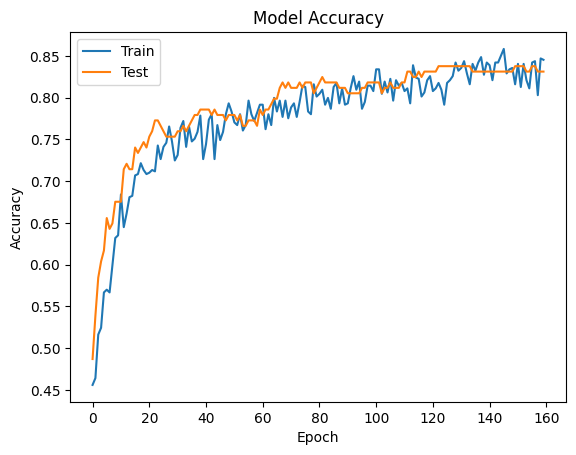

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred=model.predict(X_test)
y_pred=(y_pred>0.5)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
#

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step
[[83 16]
 [10 45]]
              precision    recall  f1-score   support

           0       0.89      0.84      0.86        99
           1       0.74      0.82      0.78        55

    accuracy                           0.83       154
   macro avg       0.82      0.83      0.82       154
weighted avg       0.84      0.83      0.83       154



In [17]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.1 MB/s eta 0:00:00


In [18]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

def build_model(hp):

    model = Sequential()

    # Number of hidden layers
    num_layers = hp.Int(
        "num_layers",
        min_value=1,
        max_value=4
    )

    for i in range(num_layers):

        # Neurons
        units = hp.Int(
            f"units_{i}",
            min_value=4,
            max_value=64,
            step=4
        )

        # Activation
        activation = hp.Choice(
            f"activation_{i}",
            ["relu", "tanh"]
        )

        model.add(
            Dense(
                units=units,
                activation=activation
            )
        )

        # Batch Normalization
        use_bn = hp.Boolean(f"batch_norm_{i}")

        if use_bn:
            model.add(BatchNormalization())

        # Dropout
        dropout = hp.Float(
            f"dropout_{i}",
            min_value=0.0,
            max_value=0.5,
            step=0.1
        )

        if dropout > 0:
            model.add(Dropout(dropout))

    # Output layer
    model.add(Dense(1, activation="sigmoid"))

    # Optimizer
    optimizer_name = hp.Choice(
        "optimizer",
        ["adam", "rmsprop", "sgd"]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        [0.0001, 0.001, 0.01]
    )

    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=learning_rate)

    elif optimizer_name == "rmsprop":
        optimizer = RMSprop(learning_rate=learning_rate)

    else:
        optimizer = SGD(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [24]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=1,
    directory="tuning",
    project_name="pima_diabetes"
)

Reloading Tuner from tuning/pima_diabetes/tuner0.json


In [22]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [25]:
tuner.search(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best number of layers:",
      best_hp.get("num_layers"))

print("Best optimizer:",
      best_hp.get("optimizer"))

print("Best learning rate:",
      best_hp.get("learning_rate"))

Trial 20 Complete [00h 00m 22s]
val_accuracy: 0.7479674816131592

Best val_accuracy So Far: 0.934959352016449
Total elapsed time: 00h 10m 02s


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 48 (192.00 B)

Best number of layers: 1
Best optimizer: rmsprop
Best learning rate: 0.01


In [26]:
for i in range(best_hp.get("num_layers")):
    print(
        "Layer", i+1,
        "neurons =", best_hp.get(f"units_{i}"),
        "activation =", best_hp.get(f"activation_{i}"),
        "batch norm =", best_hp.get(f"batch_norm_{i}"),
        "dropout =", best_hp.get(f"dropout_{i}")
    )

Layer 1 neurons = 24 activation = relu batch norm = True dropout = 0.4


In [29]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp)

In [30]:
print("Layers:", best_hp.get("num_layers"))

for i in range(best_hp.get("num_layers")):
    print("Neurons:", best_hp.get(f"units_{i}"))
    print("Activation:", best_hp.get(f"activation_{i}"))
    print("BatchNorm:", best_hp.get(f"batch_norm_{i}"))
    print("Dropout:", best_hp.get(f"dropout_{i}"))

print("Optimizer:", best_hp.get("optimizer"))
print("Learning rate:", best_hp.get("learning_rate"))

Layers: 1
Neurons: 24
Activation: relu
BatchNorm: True
Dropout: 0.4
Optimizer: rmsprop
Learning rate: 0.01


In [31]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import RMSprop

model = Sequential()

model.add(Dense(24, activation='relu', input_dim=8))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=RMSprop(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[callback]
)
model.evaluate(X_test, y_test)
from sklearn.metrics import classification_report

y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7230 - loss: 0.5968 - val_accuracy: 0.7805 - val_loss: 0.4783
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7760 - loss: 0.5012 - val_accuracy: 0.7561 - val_loss: 0.4752
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7800 - loss: 0.4908 - val_accuracy: 0.7317 - val_loss: 0.4579
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7678 - loss: 0.4644 - val_accuracy: 0.7398 - val_loss: 0.4517
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8004 - loss: 0.4494 - val_accuracy: 0.7236 - val_loss: 0.4684
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8289 - loss: 0.4154 - val_accuracy: 0.7236 - val_loss: 0.4467
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8106 - loss: 0.4257 - val_accuracy: 0.7317 - val_loss: 0.4541
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8167 - loss: 0.4137 - val_accuracy: 0.74

In [34]:
model2=tuner.get_best_models(num_models=1)[0]
model2.fit(X_train,y_train,validation_split=0.2,epochs=200,batch_size=32,callbacks=[callback])
model2.evaluate(X_test,y_test)

Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8493 - loss: 0.3511 - val_accuracy: 0.9268 - val_loss: 0.2332
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8493 - loss: 0.3578 - val_accuracy: 0.9106 - val_loss: 0.2462
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8411 - loss: 0.3613 - val_accuracy: 0.9106 - val_loss: 0.2297
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8493 - loss: 0.3628 - val_accuracy: 0.9268 - val_loss: 0.2329
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8371 - loss: 0.3823 - val_accuracy: 0.9350 - val_loss: 0.2334
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8513 - loss: 0.3845 - val_accuracy: 0.9024 - val_loss: 0.2503
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8615 - loss: 0.3609 - val_accuracy: 0.9268 - val_loss: 0.2249
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8635 - loss: 0.3440 - val_accuracy: 0.9350 - val_l

[0.4701242446899414, 0.8376623392105103]

In [35]:
y_pred=model2.predict(X_test)
y_pred=(y_pred>0.5)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
#

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[82 17]
 [ 8 47]]
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        99
           1       0.73      0.85      0.79        55

    accuracy                           0.84       154
   macro avg       0.82      0.84      0.83       154
weighted avg       0.85      0.84      0.84       154

